In [1]:
import numpy as np
import xarray as xr
from cftime import num2date, date2num
import toml
import munch
from tqdm import tqdm
import torch
import calendar
import datetime

import warnings
warnings.filterwarnings("ignore")

from Fires._utilities.utils_mlflow import load_model_from_mlflow
from Fires._utilities.utils_inference import get_scaler, process_and_plot_cmip6infer, aggregate_var

In [2]:
config = munch.munchify(toml.load("/home/jovyan/work/codes/ML4Fires/config/cmip6_inference.toml"))
searfire_ds_path = "/home/jovyan/data/ML4Fires_data/data_100km.zarr"
seafire_ds = xr.open_zarr(searfire_ds_path)

In [3]:
n_prior_days = 8
str_dates = ['2030-01-08','2050-12-24'] #[start_date, end_date] yyyy-mm-dd
np_dates = [np.datetime64(f"{str_date}T12:00:00.00") for str_date in str_dates]
date = np_dates[0]
while date < np_dates[1]:
    if date.astype(datetime.datetime).month == 2 and date.astype(datetime.datetime).day == 29:
        pass
    date += np.timedelta64(n_prior_days, "D")
    np_dates.append(date)

dates_range_np = [[np_date - np.timedelta64(n_prior_days-1, "D"), np_date] for np_date in np_dates]

In [4]:
dates_range_cfttime = []
for single_date_range in dates_range_np:
    py_date = []
    for single_np_date in single_date_range:
        if single_np_date.astype(datetime.datetime).month != 2 and single_np_date.astype(datetime.datetime).day != 29:
            py_date.append(single_np_date.astype('datetime64[ms]').astype(object))
        else:
            single_np_date -= np.timedelta64(1, "D")
            py_date.append(single_np_date.astype('datetime64[ms]').astype(object))
    units = "days since 0000-01-01"
    # calendar_type = "standard" if calendar.isleap(int(str(single_date_range[0])[0:4])) else "noleap"
    calendar_type = "noleap"
    numeric_time = date2num(py_date, units, calendar_type, has_year_zero=True)
    dates_range_cfttime.append(num2date(numeric_time, units, calendar_type, has_year_zero=True))


In [5]:
import os

cmip6_var_filename = {}
for var_key, var_value in config.data.drivers.items():
    cmip6_var_filename[var_key] = []
    if var_value.type == "dynamic":
        path_to_files = os.path.join(config.config.base_dir,var_value.cmip6_path.replace("[scenario]", config.config.cmip6_scenario))
        list_of_files = [file for file in os.listdir(path_to_files) if file.endswith(".nc")]
        for file in list_of_files:
            date = file.split("_")[-1].split(".")[0].split("-")
            start_date = np.datetime64(f"{date[0][0:4]}-{date[0][4:6]}-{date[0][6:8]}")
            end_date = np.datetime64(f"{date[1][0:4]}-{date[1][4:6]}-{date[1][6:8]}")
            for date_range in dates_range_np:
                if min(date_range) >= start_date and max(date_range)<=end_date and f"{path_to_files}{file}" not in cmip6_var_filename[var_key]:
                    cmip6_var_filename[var_key].append(f"{path_to_files}{file}")
    else:
        path_to_file = os.path.join(config.config.base_dir,var_value.cmip6_path.replace("[scenario]", config.config.cmip6_scenario))
        file = [file for file in os.listdir(path_to_file) if file.endswith(".nc")]
        cmip6_var_filename[var_key] = f"{path_to_file}/{file[0]}"
        
        

In [6]:
cmip6_var_filename

{'lai': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp585/r1i1p1f1/Eday/lai/gn/v20210126/lai_Eday_CMCC-ESM2_ssp585_r1i1p1f1_gn_20150101-20641231.nc'],
 'tas': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp585/r1i1p1f1/day/tas/gn/v20210126/tas_day_CMCC-ESM2_ssp585_r1i1p1f1_gn_20400101-20641231.nc',
  '/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp585/r1i1p1f1/day/tas/gn/v20210126/tas_day_CMCC-ESM2_ssp585_r1i1p1f1_gn_20150101-20391231.nc'],
 'hur': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp585/r1i1p1f1/day/hur/gn/v20210126/hur_day_CMCC-ESM2_ssp585_r1i1p1f1_gn_20310101-20321231.nc',
  '/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp585/r1i1p1f1/day/hur/gn/v20210126/hur_day_CMCC-ESM2_ssp585_r1i1p1f1_gn_20390101-20401231.nc',
  '/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp585/r1i1p1f1/day/hur/gn/v20210126/hur_day_CMCC-ESM2_ssp585_r1i1p1f1_gn_20350101-20361231.nc',
  '/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp585/r1i1p1f1

In [7]:
var_ds_list = []
for var_name, var_file in cmip6_var_filename.items():
    if config.data.drivers[var_name].aggregation.lower() != "none":
        ds_var = xr.open_mfdataset(var_file)[var_name]
        ds_var_time_slices = []
        for single_range_cfttime in dates_range_cfttime:
            var_time_slice = ds_var.sel(time=slice(single_range_cfttime[0],single_range_cfttime[1]))
            ds_var_time_slices.append(var_time_slice)
    else:
        ds_var = xr.open_dataset(var_file)[var_name]/100 # divide by 100 to get the same units as training dataset
    if config.data.drivers[var_name].aggregation.lower() != "none":
        for slice_idx, single_time_slice in enumerate(ds_var_time_slices):
            if var_name == "pr":
                single_time_slice = single_time_slice*3600*24 # Convering flux to total precipitation
            ds_var_time_slices[slice_idx] = aggregate_var(dataset=single_time_slice,method=config.data.drivers[var_name].aggregation,dim='time')
            ds_var_time_slices[slice_idx] = ds_var_time_slices[slice_idx].expand_dims({"time":[dates_range_np[slice_idx][-1]]})
    
        ds_var = xr.concat(ds_var_time_slices, dim="time")
    ds_var = ds_var.assign_coords({"lon": ((ds_var.lon + 180) % 360) - 180}).sortby("lon") # translating the longitude values
    ds_var = ds_var.rename({"lon":"longitude", "lat":"latitude"}) # renaming longitude and latitude for regridding
    ds_var = ds_var.interp_like(seafire_ds[["longitude","latitude"]])
    var_ds_list.append(ds_var)
                                      
ds = xr.merge(var_ds_list)
ds = ds.isel(plev=0) # This is selected for the variable which also dependso on the pressure - this selects the sea level pressure
ds_array = ds.to_array().transpose("time", "variable", "latitude", "longitude").values

In [8]:
# run_name=input()
run_name="last"
registered_model = load_model_from_mlflow(run_name, provenance=True)
# registered_model

Data from MLFlow downloaded in: /home/jovyan/work/codes/ML4Fires/MLFLOW/last


2025/04/30 18:33:21 WARNING mlflow.pytorch: Stored model version '2.4.1+cu121' does not match installed PyTorch version '2.4.1+cu124'


In [9]:
scaler = get_scaler(run_name=run_name)
transformed_ds = scaler.transform(torch.as_tensor(ds_array))
transformed_ds = transformed_ds.float()
transformed_ds = torch.nan_to_num(transformed_ds,nan=0)

prediction_cpu = []
with torch.no_grad():
    for idx in range(transformed_ds.shape[0]):
        prediction = registered_model(transformed_ds[idx].unsqueeze(0).to('cuda:0'))
        prediction_cpu.append(prediction.cpu().detach().numpy())
predictions = np.vstack(prediction_cpu).squeeze()


In [10]:
transformed_ds.shape

torch.Size([959, 6, 180, 360])

In [11]:
ds_predictions = xr.Dataset(data_vars={"global_burned_areas":(("time","latitude","longitude"),predictions)},
                            coords={"time":("time", np_dates), "longitude":("longitude", seafire_ds.longitude.values),
                                    "latitude":("latitude", seafire_ds.latitude.values)},
                           attrs={"Details": f"CMIP6 prediction for the scenario {config.config.cmip6_scenario} between the dates {min(np_dates)} and {max(np_dates)}. Prediction is made for the InterTwin Project.",
                                  "Processing": "No information",
                                 "Source": "CMCC Foundation."})

In [12]:
ds_predictions = ds_predictions.sortby(variables="time")

['lai', 'lst_day', 'rel_hum', 'sst', 't2m_min', 'tp', 'lsm'] 
 ['fcci_ba']
(180, 360)
 Mean of data: (180, 360)
 Max: 3631.659912109375 	 Min: 0.0
 Lats Max: 243.50999450683594 	 Lons Max: 143.1199951171875
 Mean of data: (180, 360)
 Max: 1808.02001953125 	 Min: 0.0
 Lats Max: 121.0199966430664 	 Lons Max: 60.31999969482422


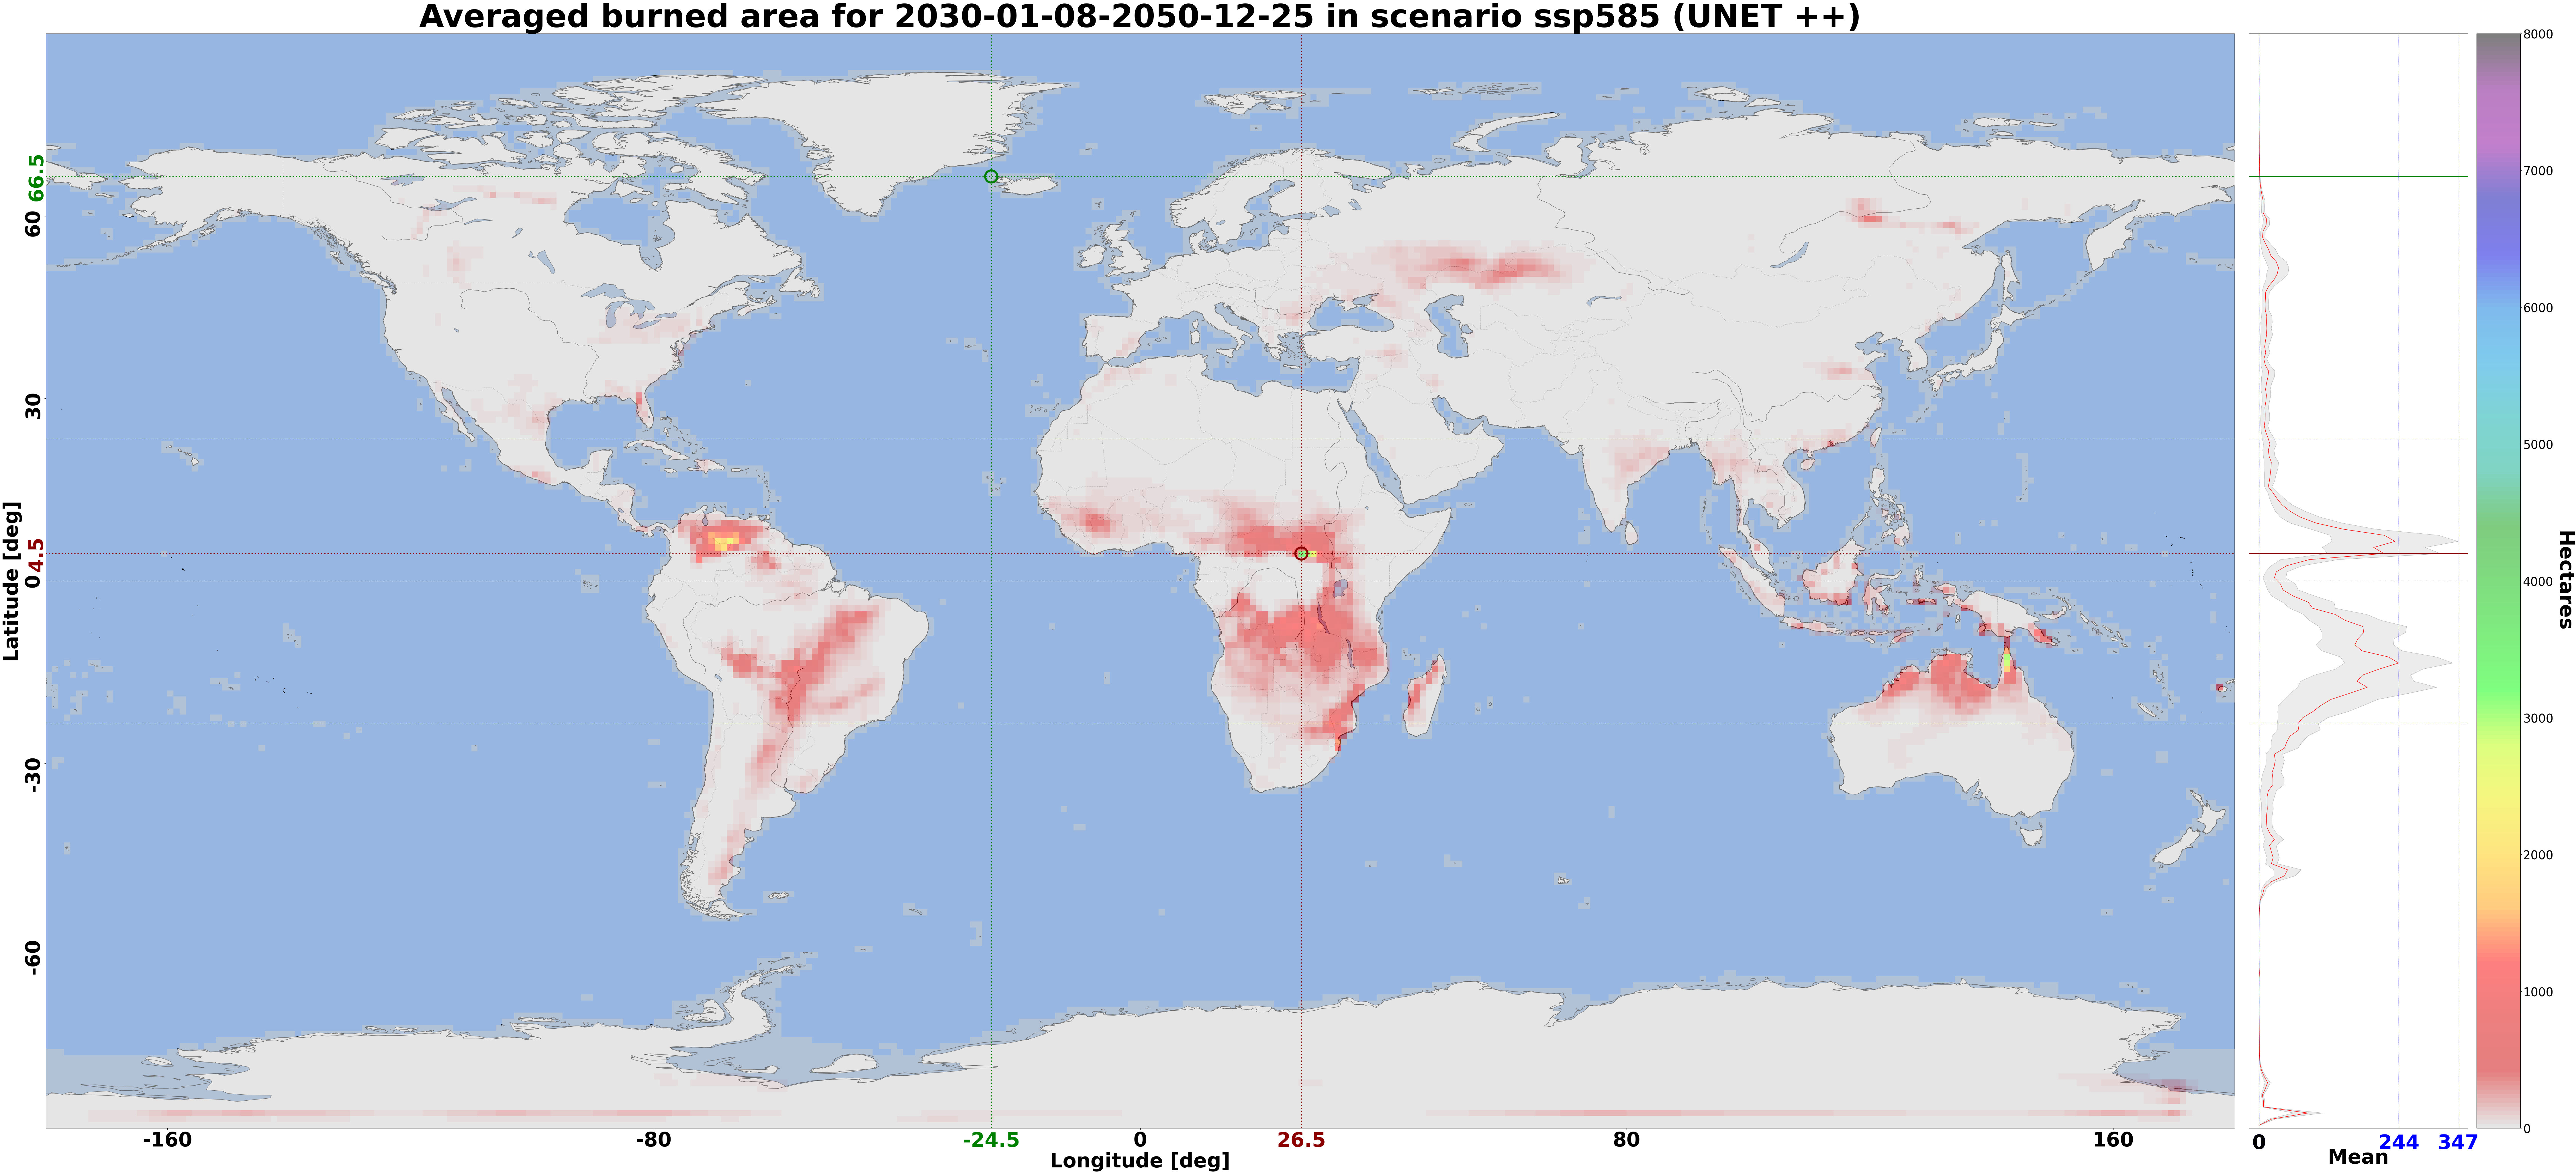

In [16]:
from Fires._utilities.utils_inference import process_and_plot_data, load_input_data

input_data = load_input_data(searfire_ds_path, '2019', '2020')

process_and_plot_cmip6infer(
	data=ds_predictions["global_burned_areas"],
	temporal_aggregate_scheme=["mean","mean","mean"],
	label=f'Averaged burned area for {str(min(np_dates))[0:10]}-{str(max(np_dates))[0:10]} in scenario {config.config.cmip6_scenario}',
	lats=seafire_ds.latitude.values,
	lons=seafire_ds.longitude.values,
	model_name="Unet ++"
)